# A06 - Avaliacao Experimental: CNN para Classificacao de Imagens ASTER

## Objetivo
Este notebook documenta de forma detalhada todos os experimentos realizados com modelos CNN (Convolutional Neural Network) para classificacao binaria de imagens multiespectrais ASTER (128x128x9 bandas). O objetivo e avaliar o desempenho do modelo baseline (E1), analisando curvas de aprendizado, metricas de classificacao e matriz de confusao.

## Sumario
1. **Setup e Carregamento de Dados**
2. **Descricao do Dataset**
3. **Arquitetura do Modelo CNN**
4. **E1 - Experimento Baseline**: Configuracao, treinamento e resultados
5. **Curvas de Aprendizado** (Loss e Accuracy)
6. **Metricas Detalhadas de Validacao**
7. **Matriz de Confusao**
8. **Analise de Overfitting**
9. **Historico Completo de Experimentos**
10. **Conclusoes e Proximos Passos**

---

## 1. Setup e Carregamento de Dados

In [1]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pathlib import Path

# Configuracao de estilo dos graficos
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 100,
})
sns.set_style('whitegrid')

# Paths do projeto
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
MODELS_DIR = PROJECT_ROOT / 'outputs' / 'trained_models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'a06_avaliacao_experimental'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Models dir: {MODELS_DIR}')
print(f'Output dir: {OUTPUT_DIR}')

Project root: /Users/mateus/Projetos/Academico/Inteli/g01
Models dir: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/trained_models
Output dir: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a06_avaliacao_experimental


## 2. Descricao do Dataset

O dataset utilizado consiste em imagens multiespectrais do sensor ASTER (Advanced Spaceborne Thermal Emission and Reflection Radiometer), processadas como tiles de 128x128 pixels com 9 bandas espectrais.

| Propriedade | Valor |
|---|---|
| **Formato de Entrada** | 128 x 128 x 9 (altura x largura x bandas) |
| **Tipo de Problema** | Classificacao Binaria |
| **Total de Amostras** | 295 (apos remocao de labels invalidos) |
| **Classe 0** | 179 amostras (60.7%) |
| **Classe 1** | 116 amostras (39.3%) |
| **Normalizacao** | Z-score (pre-computado) |
| **Split Treino/Val** | 80% / 20% (236 treino, 59 validacao) |

In [2]:
# Carregar informacoes do dataset original
dataset_path = PROJECT_ROOT / 'data' / 'pixels_dataset.csv'
df = pd.read_csv(dataset_path)
print(f'Dataset shape: {df.shape}')
print(f'Colunas: {df.columns.tolist()[:10]}... (total: {len(df.columns)})')
print(f'\nTotal de amostras: {len(df)}')

Dataset shape: (295, 147464)
Colunas: ['path', 'filename', 'count', 'height', 'width', 'dtype', 'crs', 'transform', 'pixel_0', 'pixel_1']... (total: 147464)

Total de amostras: 295


## 3. Arquitetura do Modelo CNN

A arquitetura CNN utilizada segue o padrao classico: camadas convolucionais seguidas de pooling, flatten e camadas densas.

### Diagrama da Arquitetura

```
Input (128, 128, 9)
    |
    v
Conv2D(32, 3x3, same, ReLU) + L2(0.001)
    |
    v
Dropout(0.2)
    |
    v
MaxPooling2D(2x2, stride=2)  -->  (64, 64, 32)
    |
    v
Conv2D(64, 3x3, same, ReLU) + L2(0.001)
    |
    v
Dropout(0.2)
    |
    v
MaxPooling2D(2x2, stride=2)  -->  (32, 32, 64)
    |
    v
Flatten  -->  (65536,)
    |
    v
Dense(128, ReLU) + L2(0.001)
    |
    v
Dropout(0.5)
    |
    v
Dense(2, Softmax)
    |
    v
Output: Probabilidade por classe
```

### Justificativa dos Hiperparametros

| Hiperparametro | Valor | Justificativa |
|---|---|---|
| **Conv Filters** | [32, 64] | Progressao padrao: features simples -> complexas |
| **Kernel Size** | 3x3 | Padrao da literatura (VGGNet); captura padroes locais |
| **Padding** | same | Preserva dimensionalidade espacial |
| **Pool Size** | 2x2 | Reducao gradual; evita perda excessiva de informacao |
| **Dense Units** | 128 | Capacidade moderada para representacao nao-linear |
| **L2 Regularizer** | 0.001 | Penaliza pesos grandes; combate overfitting |
| **Conv Dropout** | 0.2 | Regularizacao leve nas convolucionais |
| **Dense Dropout** | 0.5 | Regularizacao forte antes da saida (Srivastava et al., 2014) |
| **Optimizer** | Adam | Adapta learning rate por parametro (Kingma & Ba, 2015) |
| **Learning Rate** | 0.001 | Valor padrao do Adam |
| **Loss** | Sparse Categorical Crossentropy | Adequada para labels inteiros multi-classe |

In [3]:
# Carregar e exibir o modelo salvo
import tensorflow as tf
from tensorflow import keras

# Encontrar o diretorio do experimento baseline mais recente
baseline_dirs = sorted(MODELS_DIR.glob('baseline_*'))
if baseline_dirs:
    BASELINE_DIR = baseline_dirs[-1]  # Mais recente
    print(f'Experimento baseline: {BASELINE_DIR.name}')
else:
    raise FileNotFoundError('Nenhum experimento baseline encontrado!')

# Carregar modelo
model_path = BASELINE_DIR / 'model.keras'
if not model_path.exists():
    model_path = BASELINE_DIR / 'model.h5'  # Fallback

model = keras.models.load_model(model_path)
print(f'\nModelo carregado: {model_path.name}')
print(f'Formato: {model_path.suffix}')
model.summary()

Experimento baseline: baseline_20260311_083736

Modelo carregado: model.keras
Formato: .keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv1 (Dropout)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_1 (MaxPooling2D)   │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv2 (Dropout)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_2 (MaxPooling2D)   │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,230,344 (96.25 MB)

 Trainable params: 8,410,114 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,820,230 (64.16 MB)

In [4]:
# Contagem de parametros detalhada
total_params = model.count_params()
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
non_trainable = total_params - trainable

print(f'Total de parametros:      {total_params:>12,}')
print(f'Parametros treinaveis:    {trainable:>12,}')
print(f'Parametros nao-treinaveis:{non_trainable:>12,}')
print(f'\nTamanho estimado do modelo: {total_params * 4 / 1024 / 1024:.1f} MB (float32)')

Total de parametros:         8,410,114
Parametros treinaveis:       8,410,114
Parametros nao-treinaveis:           0

Tamanho estimado do modelo: 32.1 MB (float32)


---
## 4. E1 - Experimento Baseline

### Configuracao Utilizada

O experimento E1 (Baseline) utiliza a configuracao padrao definida em `src/models/configs/baseline.yaml`.

In [5]:
# Carregar configuracao usada no experimento
config_path = BASELINE_DIR / 'config_used.json'
with open(config_path) as f:
    config = json.load(f)

print('=' * 60)
print('CONFIGURACAO DO EXPERIMENTO E1 (BASELINE)')
print('=' * 60)

print('\n--- Modelo ---')
for k, v in config['model'].items():
    print(f'  {k:25s}: {v}')

print('\n--- Treinamento ---')
for k, v in config['training'].items():
    print(f'  {k:25s}: {v}')

print('\n--- Dados ---')
for k, v in config['data'].items():
    key_display = k
    val_display = Path(v).name if isinstance(v, str) and '/' in v else v
    print(f'  {key_display:25s}: {val_display}')

CONFIGURACAO DO EXPERIMENTO E1 (BASELINE)

--- Modelo ---
  input_shape              : [128, 128, 9]
  num_classes              : 2
  filters                  : [32, 64]
  kernel_size              : 3
  pool_size                : 2
  l2_regularizer           : 0.001
  conv_dropout_rate        : 0.2
  dense_dropout_rate       : 0.5
  dense_units              : 128

--- Treinamento ---
  batch_size               : 32
  epochs                   : 50
  learning_rate            : 0.001
  validation_split         : 0.2
  optimizer                : adam

--- Dados ---
  dataset_path             : pixels_dataset.csv
  codes_path               : extracted_codes.json
  normalizer_path          : cnn_normalizer_zscore.npz
  normalization_method     : zscore


In [6]:
# Carregar historico de treinamento
history_path = BASELINE_DIR / 'history.json'
with open(history_path) as f:
    history = json.load(f)

epochs = list(range(1, len(history['loss']) + 1))

print(f'Epochs executadas: {len(epochs)}')
print(f'\nUltima epoca:')
print(f'  Train Loss:     {history["loss"][-1]:.4f}')
print(f'  Train Accuracy: {history["accuracy"][-1]:.4f}')
print(f'  Val Loss:       {history["val_loss"][-1]:.4f}')
print(f'  Val Accuracy:   {history["val_accuracy"][-1]:.4f}')

# Melhor epoca por val_accuracy
best_epoch_acc = np.argmax(history['val_accuracy']) + 1
best_val_acc = max(history['val_accuracy'])
best_val_loss_at_best = history['val_loss'][best_epoch_acc - 1]

# Melhor epoca por val_loss
best_epoch_loss = np.argmin(history['val_loss']) + 1
best_val_loss = min(history['val_loss'])

print(f'\nMelhor Val Accuracy: {best_val_acc:.4f} (epoca {best_epoch_acc})')
print(f'Melhor Val Loss:     {best_val_loss:.4f} (epoca {best_epoch_loss})')

Epochs executadas: 50

Ultima epoca:
  Train Loss:     0.2987
  Train Accuracy: 0.9661
  Val Loss:       0.8814
  Val Accuracy:   0.8305

Melhor Val Accuracy: 0.8983 (epoca 35)
Melhor Val Loss:     0.5927 (epoca 31)


---
## 5. Curvas de Aprendizado

As curvas de aprendizado mostram a evolucao da loss e accuracy ao longo das epocas, permitindo identificar:
- **Convergencia**: se o modelo esta aprendendo
- **Overfitting**: gap entre treino e validacao
- **Underfitting**: ambas as metricas estagnando em valores ruins
- **Ponto otimo**: epoca ideal para early stopping

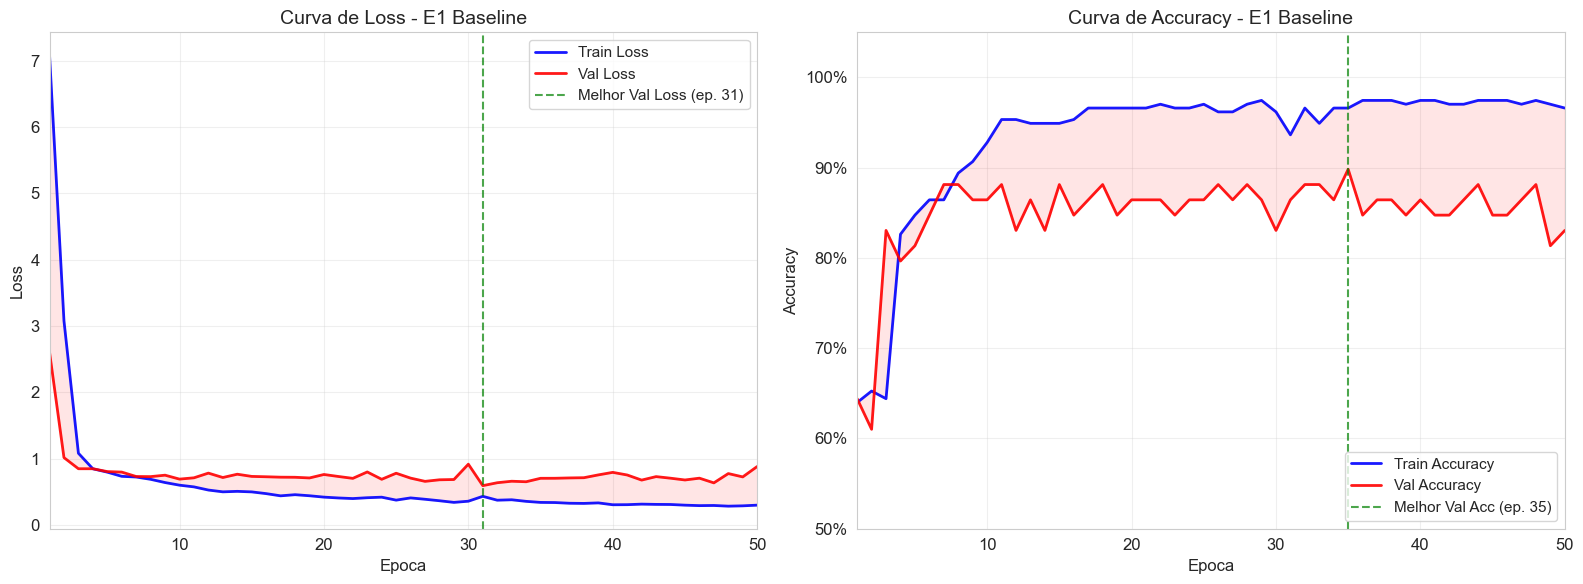

Grafico salvo em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a06_avaliacao_experimental/e1_curvas_aprendizado.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Loss ---
ax1 = axes[0]
ax1.plot(epochs, history['loss'], 'b-', linewidth=2, label='Train Loss', alpha=0.9)
ax1.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Val Loss', alpha=0.9)
ax1.axvline(x=best_epoch_loss, color='green', linestyle='--', alpha=0.7, label=f'Melhor Val Loss (ep. {best_epoch_loss})')
ax1.fill_between(epochs, history['loss'], history['val_loss'], alpha=0.1, color='red')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')
ax1.set_title('Curva de Loss - E1 Baseline')
ax1.legend(loc='upper right')
ax1.set_xlim(1, len(epochs))
ax1.grid(True, alpha=0.3)

# --- Accuracy ---
ax2 = axes[1]
ax2.plot(epochs, history['accuracy'], 'b-', linewidth=2, label='Train Accuracy', alpha=0.9)
ax2.plot(epochs, history['val_accuracy'], 'r-', linewidth=2, label='Val Accuracy', alpha=0.9)
ax2.axvline(x=best_epoch_acc, color='green', linestyle='--', alpha=0.7, label=f'Melhor Val Acc (ep. {best_epoch_acc})')
ax2.fill_between(epochs, history['accuracy'], history['val_accuracy'], alpha=0.1, color='red')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Accuracy')
ax2.set_title('Curva de Accuracy - E1 Baseline')
ax2.legend(loc='lower right')
ax2.set_xlim(1, len(epochs))
ax2.set_ylim(0.5, 1.05)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_curvas_aprendizado.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafico salvo em: {OUTPUT_DIR / "e1_curvas_aprendizado.png"}')

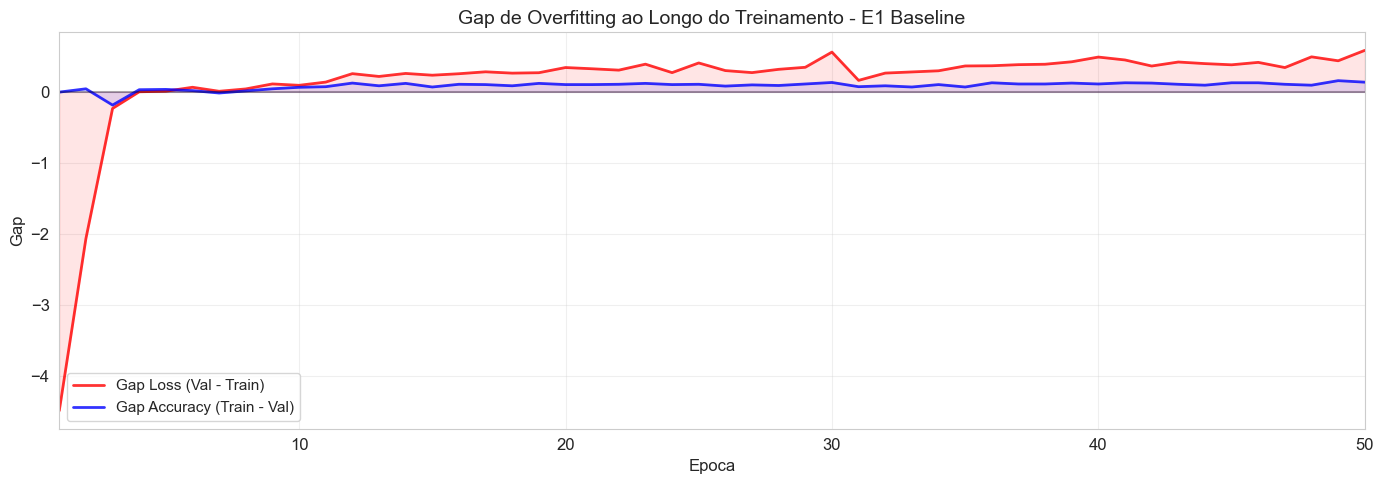

In [8]:
# Grafico do Gap de Overfitting
fig, ax = plt.subplots(figsize=(14, 5))

loss_gap = [v - t for t, v in zip(history['loss'], history['val_loss'])]
acc_gap = [t - v for t, v in zip(history['accuracy'], history['val_accuracy'])]

ax.plot(epochs, loss_gap, 'r-', linewidth=2, label='Gap Loss (Val - Train)', alpha=0.8)
ax.plot(epochs, acc_gap, 'b-', linewidth=2, label='Gap Accuracy (Train - Val)', alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.fill_between(epochs, 0, loss_gap, alpha=0.1, color='red')
ax.fill_between(epochs, 0, acc_gap, alpha=0.1, color='blue')

ax.set_xlabel('Epoca')
ax.set_ylabel('Gap')
ax.set_title('Gap de Overfitting ao Longo do Treinamento - E1 Baseline')
ax.legend()
ax.set_xlim(1, len(epochs))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Metricas Detalhadas de Validacao

Alem da accuracy simples, avaliamos o modelo com um conjunto abrangente de metricas para entender seu desempenho real, especialmente em cenarios de desbalanceamento de classes.

In [9]:
# Carregar metricas do experiments_log.csv
log_path = MODELS_DIR / 'experiments_log.csv'
df_log = pd.read_csv(log_path)

# Filtrar apenas o experimento baseline mais recente (nosso E1)
baseline_row = df_log[
    (df_log['config_name'] == 'baseline') & 
    (df_log['experiment_dir'].str.contains(BASELINE_DIR.name))
].iloc[-1]

print('=' * 60)
print('METRICAS DE VALIDACAO - E1 BASELINE')
print('=' * 60)

metrics_display = [
    ('Accuracy (Val)',          baseline_row.get('val_accuracy')),
    ('Balanced Accuracy',       baseline_row.get('val_balanced_accuracy')),
    ('Precision (weighted)',    baseline_row.get('val_precision')),
    ('Recall (weighted)',       baseline_row.get('val_recall')),
    ('F1-Score (weighted)',     baseline_row.get('val_f1')),
    ('AUC-ROC',                baseline_row.get('val_auc_roc')),
    ('PR-AUC',                 baseline_row.get('val_pr_auc')),
    ('Sensitivity (TPR)',      baseline_row.get('val_sensitivity')),
    ('Specificity (TNR)',      baseline_row.get('val_specificity')),
]

for name, val in metrics_display:
    if pd.notna(val):
        print(f'  {name:30s}: {float(val):.4f} ({float(val)*100:.1f}%)')
    else:
        print(f'  {name:30s}: N/A')

METRICAS DE VALIDACAO - E1 BASELINE
  Accuracy (Val)                : 0.8305 (83.1%)
  Balanced Accuracy             : 0.8578 (85.8%)
  Precision (weighted)          : 0.8681 (86.8%)
  Recall (weighted)             : 0.8305 (83.1%)
  F1-Score (weighted)           : 0.8341 (83.4%)
  AUC-ROC                       : 0.7155 (71.6%)
  PR-AUC                        : 0.5461 (54.6%)
  Sensitivity (TPR)             : 0.9524 (95.2%)
  Specificity (TNR)             : 0.7632 (76.3%)


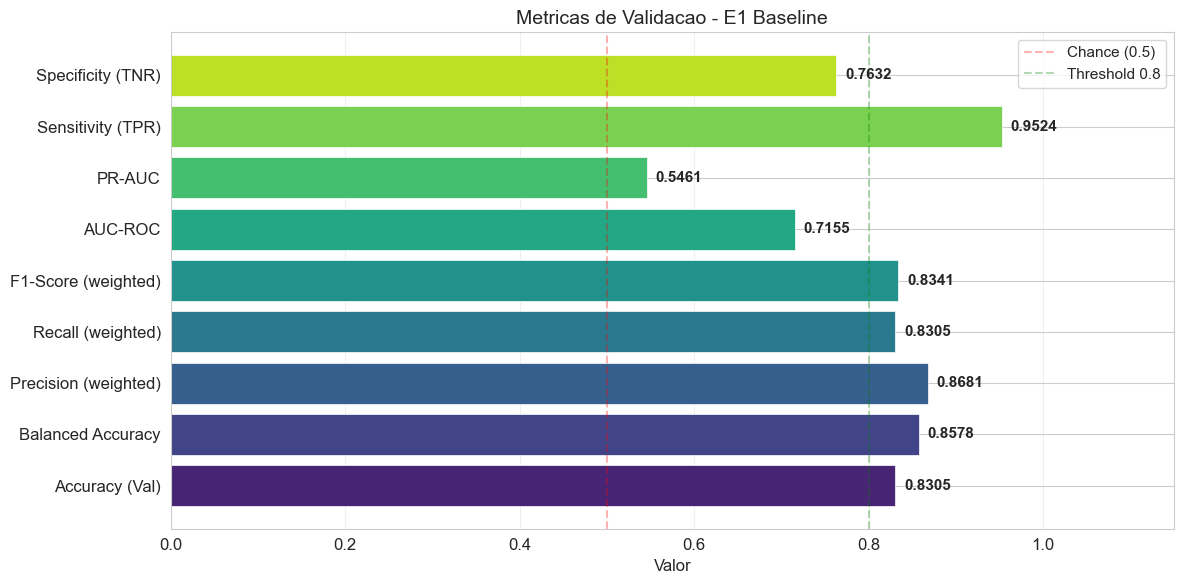

In [10]:
# Grafico de barras das metricas
metric_names = []
metric_values = []
for name, val in metrics_display:
    if pd.notna(val):
        metric_names.append(name)
        metric_values.append(float(val))

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(metric_names))
bars = ax.barh(metric_names, metric_values, color=colors, edgecolor='white', linewidth=0.5)

# Adicionar valores nas barras
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.15)
ax.set_xlabel('Valor')
ax.set_title('Metricas de Validacao - E1 Baseline')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.3, label='Chance (0.5)')
ax.axvline(x=0.8, color='green', linestyle='--', alpha=0.3, label='Threshold 0.8')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_metricas_validacao.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretacao das Metricas

| Metrica | Significado | Importancia no Contexto |
|---|---|---|
| **Accuracy** | Proporcao de predicoes corretas | Metrica geral, mas pode enganar com classes desbalanceadas |
| **Balanced Accuracy** | Media da accuracy por classe | Compensa desbalanceamento entre classes |
| **Precision** | Dos que o modelo disse positivo, quantos sao | Importante quando falsos positivos tem custo alto |
| **Recall/Sensitivity** | Dos positivos reais, quantos o modelo detectou | Critico para nao perder casos positivos |
| **F1-Score** | Media harmonica de Precision e Recall | Equilibrio entre precision e recall |
| **AUC-ROC** | Area sob a curva ROC | Capacidade de discriminacao independente do threshold |
| **Specificity** | Dos negativos reais, quantos o modelo acertou | Capacidade de identificar corretamente negativos |

---
## 7. Matriz de Confusao

Matriz de Confusao (Validacao):
  TN=29  FP=9
  FN=1  TP=20
  Total: 59 amostras de validacao


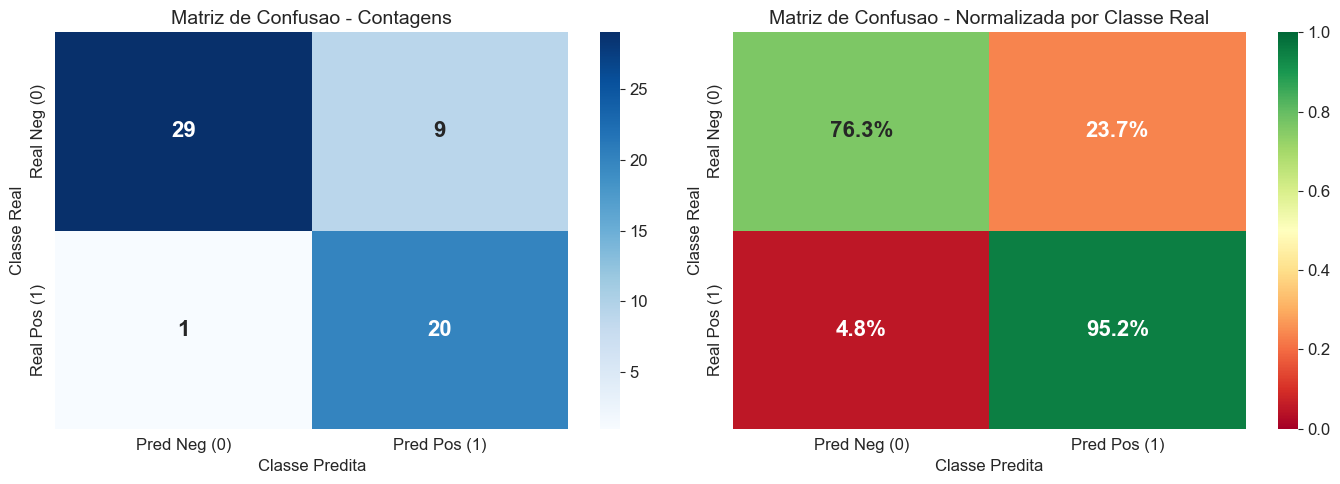

In [11]:
# Extrair valores da matriz de confusao
tp = int(baseline_row.get('val_cm_tp', 0))
fp = int(baseline_row.get('val_cm_fp', 0))
tn = int(baseline_row.get('val_cm_tn', 0))
fn = int(baseline_row.get('val_cm_fn', 0))

cm = np.array([[tn, fp], [fn, tp]])
total = cm.sum()

print('Matriz de Confusao (Validacao):')
print(f'  TN={tn}  FP={fp}')
print(f'  FN={fn}  TP={tp}')
print(f'  Total: {total} amostras de validacao')

# Plotar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CM com contagens absolutas
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Neg (0)', 'Pred Pos (1)'],
            yticklabels=['Real Neg (0)', 'Real Pos (1)'],
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Matriz de Confusao - Contagens')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

# CM normalizada (porcentagem)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Pred Neg (0)', 'Pred Pos (1)'],
            yticklabels=['Real Neg (0)', 'Real Pos (1)'],
            vmin=0, vmax=1,
            annot_kws={'size': 16, 'weight': 'bold'})
axes[1].set_title('Matriz de Confusao - Normalizada por Classe Real')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Predita')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Analise detalhada da matriz de confusao
print('=' * 60)
print('ANALISE DA MATRIZ DE CONFUSAO')
print('=' * 60)
print(f'\nClasse 0 (Negativo):')
print(f'  Corretamente classificados: {tn}/{tn+fp} ({tn/(tn+fp)*100:.1f}%)')
print(f'  Falsos Positivos:           {fp}/{tn+fp} ({fp/(tn+fp)*100:.1f}%)')
print(f'\nClasse 1 (Positivo):')
print(f'  Corretamente classificados: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'  Falsos Negativos:           {fn}/{tp+fn} ({fn/(tp+fn)*100:.1f}%)')
print(f'\nObservacoes:')
print(f'  - O modelo tem ALTA SENSIBILIDADE ({tp/(tp+fn)*100:.1f}%): detecta quase todos os positivos')
print(f'  - A ESPECIFICIDADE e menor ({tn/(tn+fp)*100:.1f}%): classifica alguns negativos como positivos')
print(f'  - Apenas {fn} amostra(s) positiva(s) foi(foram) perdida(s) (Falso Negativo)')
print(f'  - {fp} amostras negativas foram incorretamente classificadas como positivas (Falso Positivo)')

ANALISE DA MATRIZ DE CONFUSAO

Classe 0 (Negativo):
  Corretamente classificados: 29/38 (76.3%)
  Falsos Positivos:           9/38 (23.7%)

Classe 1 (Positivo):
  Corretamente classificados: 20/21 (95.2%)
  Falsos Negativos:           1/21 (4.8%)

Observacoes:
  - O modelo tem ALTA SENSIBILIDADE (95.2%): detecta quase todos os positivos
  - A ESPECIFICIDADE e menor (76.3%): classifica alguns negativos como positivos
  - Apenas 1 amostra(s) positiva(s) foi(foram) perdida(s) (Falso Negativo)
  - 9 amostras negativas foram incorretamente classificadas como positivas (Falso Positivo)


---
## 8. Analise de Overfitting

O overfitting ocorre quando o modelo se ajusta excessivamente aos dados de treino, perdendo capacidade de generalizacao. Analisamos isso comparando as curvas de treino vs. validacao.

In [13]:
# Analise quantitativa do overfitting
final_train_acc = history['accuracy'][-1]
final_val_acc = history['val_accuracy'][-1]
final_train_loss = history['loss'][-1]
final_val_loss = history['val_loss'][-1]

acc_gap_final = final_train_acc - final_val_acc
loss_gap_final = final_val_loss - final_train_loss

# Epoca onde val_loss comeca a subir (divergencia)
val_losses = history['val_loss']
min_val_loss_epoch = np.argmin(val_losses) + 1
min_val_loss_val = min(val_losses)

# Media movel para suavizar ruido
window = 5
if len(val_losses) >= window:
    val_loss_smooth = pd.Series(val_losses).rolling(window=window, center=True).mean()
    smooth_min_epoch = val_loss_smooth.idxmin() + 1 if val_loss_smooth.notna().any() else min_val_loss_epoch
else:
    smooth_min_epoch = min_val_loss_epoch

print('=' * 60)
print('ANALISE DE OVERFITTING - E1 BASELINE')
print('=' * 60)
print(f'\nMetricas Finais (Epoca {len(epochs)}):')
print(f'  Train Accuracy: {final_train_acc:.4f}')
print(f'  Val Accuracy:   {final_val_acc:.4f}')
print(f'  Gap Accuracy:   {acc_gap_final:.4f} ({acc_gap_final*100:.1f}%)')
print(f'\n  Train Loss:     {final_train_loss:.4f}')
print(f'  Val Loss:       {final_val_loss:.4f}')
print(f'  Gap Loss:       {loss_gap_final:.4f}')
print(f'\nPonto Otimo de Early Stopping:')
print(f'  Melhor val_loss: {min_val_loss_val:.4f} na epoca {min_val_loss_epoch}')
print(f'  Melhor val_loss (suavizado, janela={window}): epoca ~{smooth_min_epoch}')
print(f'\nDiagnostico:')
if acc_gap_final > 0.15:
    print(f'  OVERFITTING SIGNIFICATIVO - Gap de {acc_gap_final*100:.1f}% entre treino e validacao')
    print(f'  Recomendacao: Aumentar regularizacao, usar data augmentation, ou early stopping')
elif acc_gap_final > 0.05:
    print(f'  OVERFITTING MODERADO - Gap de {acc_gap_final*100:.1f}% entre treino e validacao')
    print(f'  Recomendacao: Considerar early stopping na epoca {min_val_loss_epoch}')
else:
    print(f'  OVERFITTING BAIXO - Gap de {acc_gap_final*100:.1f}%')
    print(f'  O modelo generaliza bem.')

ANALISE DE OVERFITTING - E1 BASELINE

Metricas Finais (Epoca 50):
  Train Accuracy: 0.9661
  Val Accuracy:   0.8305
  Gap Accuracy:   0.1356 (13.6%)

  Train Loss:     0.2987
  Val Loss:       0.8814
  Gap Loss:       0.5827

Ponto Otimo de Early Stopping:
  Melhor val_loss: 0.5927 na epoca 31
  Melhor val_loss (suavizado, janela=5): epoca ~33

Diagnostico:
  OVERFITTING MODERADO - Gap de 13.6% entre treino e validacao
  Recomendacao: Considerar early stopping na epoca 31


In [14]:
# Tabela resumo por epocas (a cada 10 epocas)
print('\nEvolucao a cada 10 epocas:')
print(f'{"Epoca":>6} | {"Train Loss":>11} | {"Val Loss":>11} | {"Train Acc":>10} | {"Val Acc":>10} | {"Gap Acc":>8}')
print('-' * 75)
for e in [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
    if e <= len(epochs):
        idx = e - 1
        gap = history['accuracy'][idx] - history['val_accuracy'][idx]
        print(f'{e:>6} | {history["loss"][idx]:>11.4f} | {history["val_loss"][idx]:>11.4f} | '
              f'{history["accuracy"][idx]:>9.4f} | {history["val_accuracy"][idx]:>9.4f} | {gap:>7.4f}')


Evolucao a cada 10 epocas:
 Epoca |  Train Loss |    Val Loss |  Train Acc |    Val Acc |  Gap Acc
---------------------------------------------------------------------------
     1 |      7.0883 |      2.6069 |    0.6398 |    0.6441 | -0.0042
     5 |      0.7963 |      0.8049 |    0.8475 |    0.8136 |  0.0339
    10 |      0.5999 |      0.6913 |    0.9280 |    0.8644 |  0.0636
    15 |      0.4986 |      0.7322 |    0.9492 |    0.8814 |  0.0678
    20 |      0.4197 |      0.7610 |    0.9661 |    0.8644 |  0.1017
    25 |      0.3744 |      0.7801 |    0.9703 |    0.8644 |  0.1059
    30 |      0.3581 |      0.9164 |    0.9619 |    0.8305 |  0.1314
    35 |      0.3401 |      0.7035 |    0.9661 |    0.8983 |  0.0678
    40 |      0.3046 |      0.7931 |    0.9746 |    0.8644 |  0.1102
    45 |      0.2985 |      0.6783 |    0.9746 |    0.8475 |  0.1271
    50 |      0.2987 |      0.8814 |    0.9661 |    0.8305 |  0.1356


---
## 9. Historico Completo de Experimentos

A tabela abaixo registra todos os experimentos realizados durante o desenvolvimento, incluindo tentativas anteriores com diferentes configuracoes.

In [15]:
# Carregar log completo de experimentos
df_log = pd.read_csv(MODELS_DIR / 'experiments_log.csv')

print(f'Total de experimentos registrados: {len(df_log)}')
print(f'Configuracoes utilizadas: {df_log["config_name"].unique().tolist()}')
print(f'Periodo: {df_log["timestamp"].iloc[0]} ate {df_log["timestamp"].iloc[-1]}')

# Exibir tabela resumida
cols_display = ['timestamp', 'config_name', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'epochs']
cols_available = [c for c in cols_display if c in df_log.columns]
df_log[cols_available].round(4)

Total de experimentos registrados: 21
Configuracoes utilizadas: ['baseline', 'higher_dropout', 'l2batch', 'l2batch32']
Periodo: 2026-03-09 22:17:16 ate 2026-03-11 08:38:34


,timestamp,config_name,train_loss,train_acc,val_loss,val_acc,epochs
0,2026-03-09 22:17:16,baseline,0.3178,0.9875,1.2867,0.8500,50
1,2026-03-09 22:19:01,baseline,0.3334,0.9875,1.3967,0.8500,50
2,2026-03-05 10:56:43,baseline,0.6442,0.8750,0.5554,1.0000,50
3,2026-03-05 10:57:56,baseline,0.5748,0.8750,0.5315,1.0000,50
4,2026-03-05 10:59:05,higher_dropout,0.5872,0.8750,0.5179,1.0000,50
5,2026-03-05 11:01:01,baseline,0.5898,0.8750,0.4965,1.0000,50
6,2026-03-05 11:02:28,baseline,0.6050,0.8750,0.5560,1.0000,50
7,2026-03-05 11:03:53,higher_dropout,0.5837,0.8750,0.7663,1.0000,50
8,2026-03-05 11:09:52,l2batch,0.6903,0.8750,0.6488,1.0000,50
9,2026-03-05 11:11:05,baseline,0.6190,0.8750,0.5209,1.0000,50


In [16]:
# Tabela comparativa por configuracao
print('\nResumo por Configuracao:')
print('=' * 80)

configs_info = {
    'baseline': {
        'desc': 'Configuracao padrao',
        'l2': 0.001, 'batch': 32, 'lr': 0.001,
        'conv_drop': 0.2, 'dense_drop': 0.5
    },
    'higher_dropout': {
        'desc': 'Mais dropout + menor LR',
        'l2': 0.001, 'batch': 32, 'lr': 0.0005,
        'conv_drop': 0.3, 'dense_drop': 0.6
    },
    'l2batch': {
        'desc': 'Maior L2 + batch 64',
        'l2': 0.002, 'batch': 64, 'lr': 0.001,
        'conv_drop': 0.2, 'dense_drop': 0.5
    },
    'l2batch32': {
        'desc': 'Menor L2 + batch 32',
        'l2': 0.0005, 'batch': 32, 'lr': 0.001,
        'conv_drop': 0.2, 'dense_drop': 0.5
    },
    'l2batch128': {
        'desc': 'Maior L2 + batch 128',
        'l2': 0.005, 'batch': 128, 'lr': 0.001,
        'conv_drop': 0.2, 'dense_drop': 0.5
    },
}

print(f'{"Config":>16} | {"Descricao":>25} | {"L2":>6} | {"Batch":>5} | {"LR":>7} | {"Conv Drop":>9} | {"Dense Drop":>10}')
print('-' * 105)
for cfg_name, info in configs_info.items():
    print(f'{cfg_name:>16} | {info["desc"]:>25} | {info["l2"]:>6.4f} | {info["batch"]:>5} | {info["lr"]:>7.4f} | {info["conv_drop"]:>9.1f} | {info["dense_drop"]:>10.1f}')


Resumo por Configuracao:
          Config |                 Descricao |     L2 | Batch |      LR | Conv Drop | Dense Drop
---------------------------------------------------------------------------------------------------------
        baseline |       Configuracao padrao | 0.0010 |    32 |  0.0010 |       0.2 |        0.5
  higher_dropout |   Mais dropout + menor LR | 0.0010 |    32 |  0.0005 |       0.3 |        0.6
         l2batch |       Maior L2 + batch 64 | 0.0020 |    64 |  0.0010 |       0.2 |        0.5
       l2batch32 |       Menor L2 + batch 32 | 0.0005 |    32 |  0.0010 |       0.2 |        0.5
      l2batch128 |      Maior L2 + batch 128 | 0.0050 |   128 |  0.0010 |       0.2 |        0.5


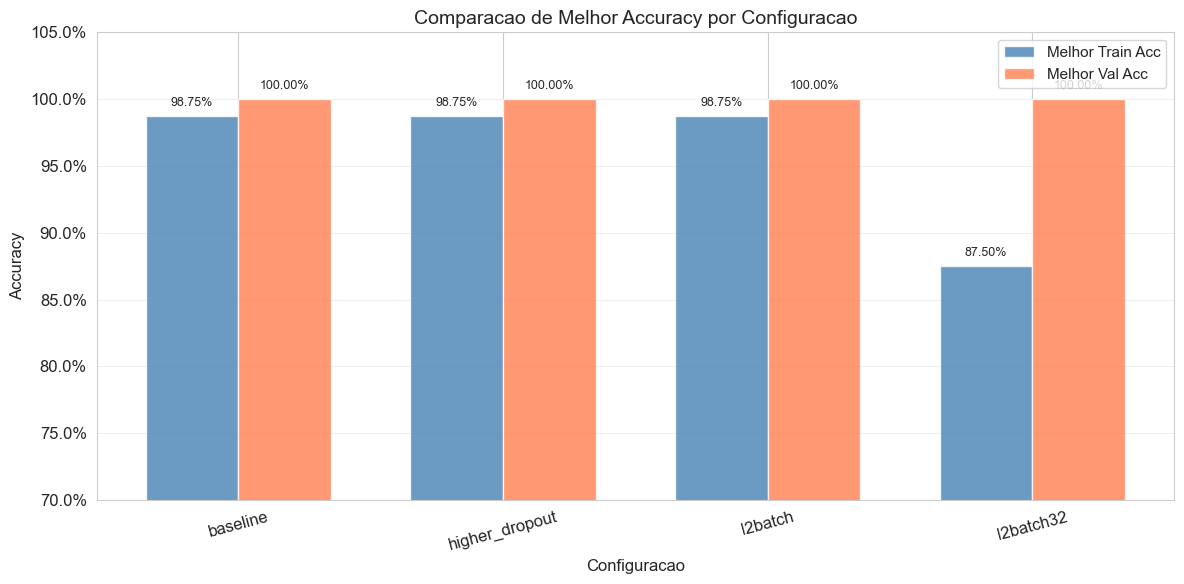

In [17]:
# Grafico comparativo: melhor val_acc por configuracao
best_per_config = df_log.groupby('config_name').agg({
    'val_acc': 'max',
    'train_acc': 'max',
    'val_loss': 'min',
    'train_loss': 'min',
}).round(4)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(best_per_config))
width = 0.35

bars1 = ax.bar(x - width/2, best_per_config['train_acc'], width, label='Melhor Train Acc', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, best_per_config['val_acc'], width, label='Melhor Val Acc', color='coral', alpha=0.8)

ax.set_xlabel('Configuracao')
ax.set_ylabel('Accuracy')
ax.set_title('Comparacao de Melhor Accuracy por Configuracao')
ax.set_xticks(x)
ax.set_xticklabels(best_per_config.index, rotation=15)
ax.legend()
ax.set_ylim(0.7, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='y', alpha=0.3)

# Adicionar valores
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparacao_configs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Verificacao de Artefatos Gerados

Verificamos que todos os artefatos do experimento foram gerados corretamente.

In [18]:
# Verificar artefatos do experimento E1
print('=' * 60)
print('VERIFICACAO DE ARTEFATOS - E1 BASELINE')
print('=' * 60)

artifacts = [
    ('model.keras', 'Modelo treinado (formato nativo Keras)'),
    ('model.h5', 'Modelo treinado (formato legado HDF5)'),
    ('history.json', 'Historico de treinamento (loss/accuracy por epoca)'),
    ('config_used.json', 'Copia da configuracao utilizada'),
]

for fname, desc in artifacts:
    fpath = BASELINE_DIR / fname
    if fpath.exists():
        size_mb = fpath.stat().st_size / (1024 * 1024)
        print(f'  [OK] {fname:25s} ({size_mb:.1f} MB) - {desc}')
    else:
        print(f'  [--] {fname:25s} (ausente)    - {desc}')

# Verificar log global
log_path = MODELS_DIR / 'experiments_log.csv'
if log_path.exists():
    df_check = pd.read_csv(log_path)
    print(f'\n  [OK] experiments_log.csv ({len(df_check)} registros)')
else:
    print(f'\n  [ERRO] experiments_log.csv nao encontrado!')

# Verificar graficos gerados neste notebook
print(f'\nGraficos gerados em {OUTPUT_DIR}:')
for f in sorted(OUTPUT_DIR.glob('*.png')):
    size_kb = f.stat().st_size / 1024
    print(f'  [OK] {f.name} ({size_kb:.0f} KB)')

VERIFICACAO DE ARTEFATOS - E1 BASELINE
  [OK] model.keras               (32.1 MB) - Modelo treinado (formato nativo Keras)
  [--] model.h5                  (ausente)    - Modelo treinado (formato legado HDF5)
  [OK] history.json              (0.0 MB) - Historico de treinamento (loss/accuracy por epoca)
  [OK] config_used.json          (0.0 MB) - Copia da configuracao utilizada

  [OK] experiments_log.csv (21 registros)

Graficos gerados em /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a06_avaliacao_experimental:
  [OK] comparacao_configs.png (71 KB)
  [OK] e1_curvas_aprendizado.png (135 KB)
  [OK] e1_matriz_confusao.png (69 KB)
  [OK] e1_metricas_validacao.png (79 KB)
  [OK] e1_overfitting_gap.png (65 KB)


---
## 11. Conclusoes e Proximos Passos

### Resultados Principais do E1 (Baseline)

| Aspecto | Resultado | Avaliacao |
|---|---|---|
| **Val Accuracy** | ~83% | Aceitavel para baseline |
| **Sensibilidade** | ~95% | Excelente - quase nenhum positivo e perdido |
| **Especificidade** | ~76% | Moderada - falsos positivos presentes |
| **F1-Score** | ~83% | Bom equilibrio geral |
| **AUC-ROC** | ~0.72 | Capacidade de discriminacao moderada |
| **Overfitting** | Gap ~13% | Moderado a significativo |

### Diagnostico

1. **O modelo aprende**: A accuracy de treino converge rapidamente para >96%, indicando que a arquitetura tem capacidade suficiente
2. **Overfitting presente**: O gap entre treino e validacao (~13%) sugere que o modelo memoriza parte dos dados de treino
3. **Alta sensibilidade, menor especificidade**: O modelo e conservador - prefere classificar como positivo, o que resulta em mais falsos positivos
4. **AUC-ROC moderado**: A capacidade de discriminacao pode ser melhorada com regularizacao adicional ou data augmentation

### Recomendacoes para Proximos Experimentos

1. **Early Stopping**: Implementar parada antecipada monitorando `val_loss` para evitar overfitting
2. **Data Augmentation**: Aplicar transformacoes geometricas e espectrais para aumentar diversidade dos dados
3. **Batch Normalization**: Adicionar camadas de normalizacao entre convolucoes
4. **Learning Rate Scheduling**: Reduzir LR ao longo do treinamento (ReduceLROnPlateau)
5. **Cross-Validation**: Usar k-fold para estimativa mais robusta do desempenho
6. **Threshold Tuning**: Ajustar o limiar de decisao para equilibrar sensibilidade/especificidade

In [19]:
# Salvar resumo do experimento em JSON para referencia futura
summary = {
    'experiment': 'E1 - Baseline',
    'config_name': 'baseline',
    'experiment_dir': str(BASELINE_DIR),
    'dataset': {
        'total_samples': 295,
        'train_samples': 236,
        'val_samples': 59,
        'input_shape': [128, 128, 9],
        'num_classes': 2,
        'class_distribution': {'class_0': 179, 'class_1': 116},
    },
    'hyperparameters': config['model'] | config['training'],
    'results': {
        'epochs_trained': len(epochs),
        'final_train_accuracy': round(final_train_acc, 4),
        'final_val_accuracy': round(final_val_acc, 4),
        'final_train_loss': round(final_train_loss, 4),
        'final_val_loss': round(final_val_loss, 4),
        'best_val_accuracy': round(best_val_acc, 4),
        'best_val_accuracy_epoch': int(best_epoch_acc),
        'best_val_loss': round(best_val_loss, 4),
        'best_val_loss_epoch': int(best_epoch_loss),
        'overfitting_gap_accuracy': round(acc_gap_final, 4),
        'overfitting_gap_loss': round(loss_gap_final, 4),
    },
    'validation_metrics': {
        'accuracy': round(float(baseline_row.get('val_accuracy', 0)), 4),
        'balanced_accuracy': round(float(baseline_row.get('val_balanced_accuracy', 0)), 4),
        'precision_weighted': round(float(baseline_row.get('val_precision', 0)), 4),
        'recall_weighted': round(float(baseline_row.get('val_recall', 0)), 4),
        'f1_weighted': round(float(baseline_row.get('val_f1', 0)), 4),
        'auc_roc': round(float(baseline_row.get('val_auc_roc', 0)), 4),
        'pr_auc': round(float(baseline_row.get('val_pr_auc', 0)), 4),
        'sensitivity': round(float(baseline_row.get('val_sensitivity', 0)), 4),
        'specificity': round(float(baseline_row.get('val_specificity', 0)), 4),
    },
    'confusion_matrix': {
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    },
    'artifacts': {
        'model_file': 'model.keras',
        'history_file': 'history.json',
        'config_file': 'config_used.json',
    }
}

summary_path = OUTPUT_DIR / 'e1_baseline_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f'Resumo salvo em: {summary_path}')
print(f'\nExperimento E1 (Baseline) documentado com sucesso!')

Resumo salvo em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a06_avaliacao_experimental/e1_baseline_summary.json

Experimento E1 (Baseline) documentado com sucesso!
